# Badminton Racket Price Prediction using XGBoost

## Phân tích và dự đoán giá vợt cầu lông với XGBoost

Notebook này thực hiện:
- One-hot encoding cho: Brand, Version, Origin, Tech_Frame, Tech_Material, Tech_Stability
- Target encoding cho: Series
- Huấn luyện mô hình XGBoost
- Đánh giá độ chính xác và thời gian chạy
- Trực quan hóa kết quả

## 1. Import Required Libraries

In [1]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore Data

In [ ]:
# Load data
df = pd.read_csv('dataprocessing_v3.csv')
df.drop('Version', axis=1, inplace=True)
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nKích thước dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nKiểu dữ liệu của các cột:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nThống kê mô tả:")
df.describe()

DATA OVERVIEW

Kích thước dataset: 6260 rows × 8 columns

Kiểu dữ liệu của các cột:
Brand              object
Series             object
Max Tension       float64
Tech_Frame         object
Tech_Material      object
Tech_Stability     object
Origin             object
Price             float64
dtype: object

Missing values:
Brand                0
Series               0
Max Tension          0
Tech_Frame        1244
Tech_Material     1056
Tech_Stability    1680
Origin               0
Price               20
dtype: int64

Thống kê mô tả:


,Max Tension,Price
count,6260.000000,6.240000e+03
mean,28.352077,2.649314e+06
std,3.095230,2.431072e+07
min,18.000000,3.599190e+05
25%,26.000000,1.098456e+06
50%,28.000000,1.590000e+06
75%,30.000000,2.739287e+06
max,38.000000,9.610075e+08


In [17]:
# Hiển thị 5 dòng đầu tiên
print("\nDữ liệu mẫu:")
df.head()


Dữ liệu mẫu:


,Brand,Series,Max Tension,Tech_Frame,Tech_Material,Tech_Stability,Origin,Price
0,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1140000.0
1,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1140007.0
2,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1139947.0
3,Lining,1210F,28.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM",AIR SYSTEM,China,1139966.0
4,Lining,3D,30.0,OPTIMUM FRAME,"TB NANO, AEROTEC BEAM","WING STABILIZER, 3D CALIBAR, STABILIZED TORSIO...",China,1150000.0


## 3. Data Visualization & Exploratory Data Analysis

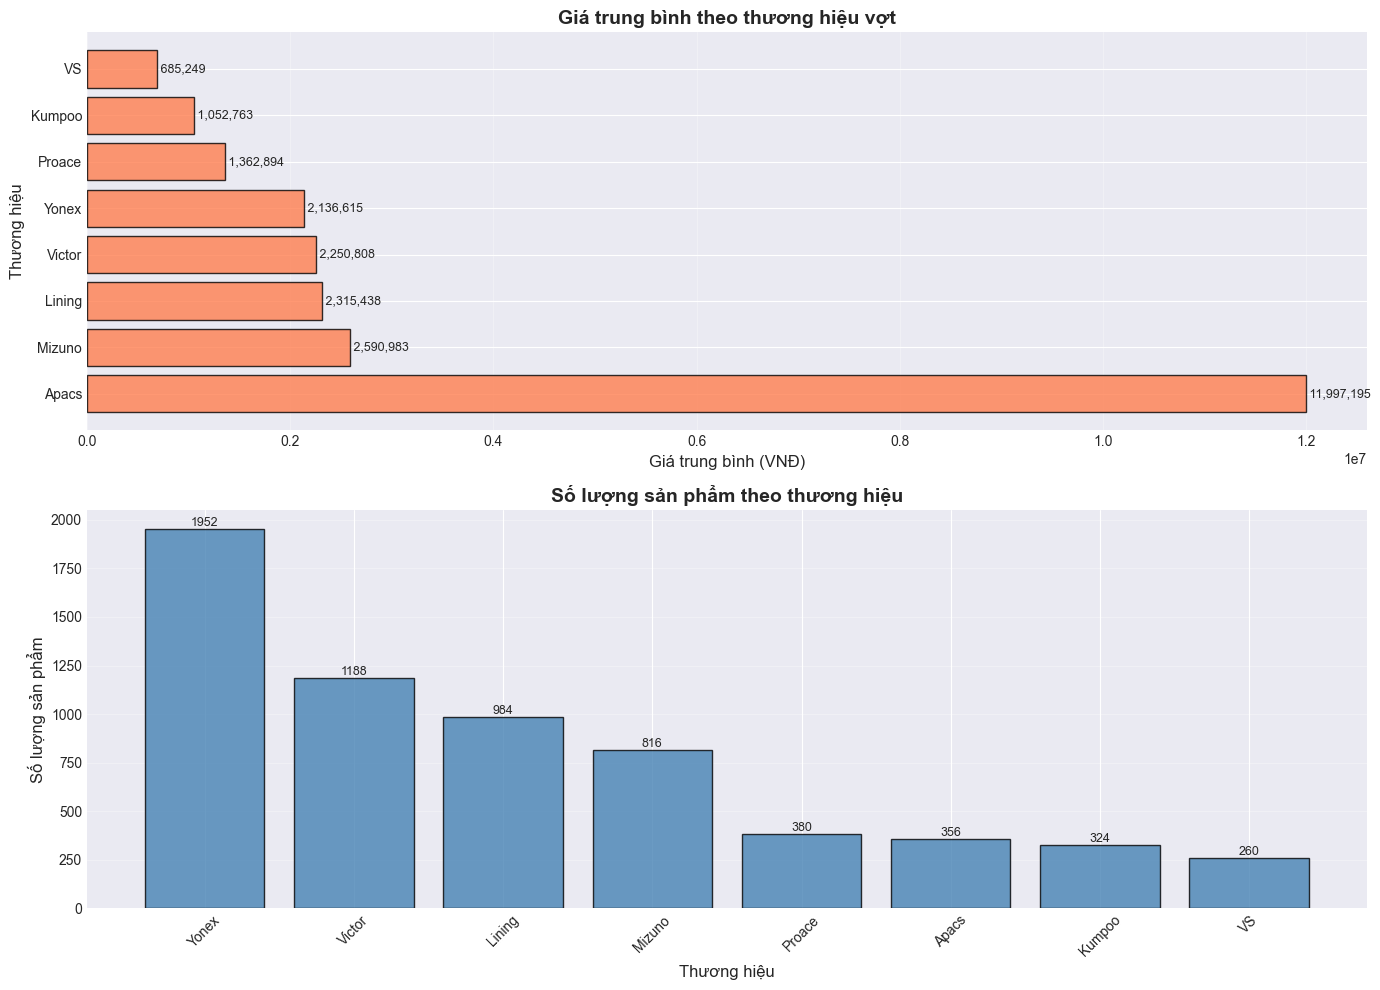

In [19]:
# Giá trung bình theo thương hiệu
brand_price = df.groupby('Brand')['Price'].agg(['mean', 'count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar plot - Giá trung bình theo Brand
axes[0].barh(brand_price.index, brand_price['mean'], color='coral', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Giá trung bình (VNĐ)', fontsize=12)
axes[0].set_ylabel('Thương hiệu', fontsize=12)
axes[0].set_title('Giá trung bình theo thương hiệu vợt', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Thêm values lên bars
for i, v in enumerate(brand_price['mean']):
    axes[0].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

# Bar plot - Số lượng sản phẩm theo Brand
brand_count = df['Brand'].value_counts()
axes[1].bar(brand_count.index, brand_count.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Thương hiệu', fontsize=12)
axes[1].set_ylabel('Số lượng sản phẩm', fontsize=12)
axes[1].set_title('Số lượng sản phẩm theo thương hiệu', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Thêm values lên bars
for i, v in enumerate(brand_count.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

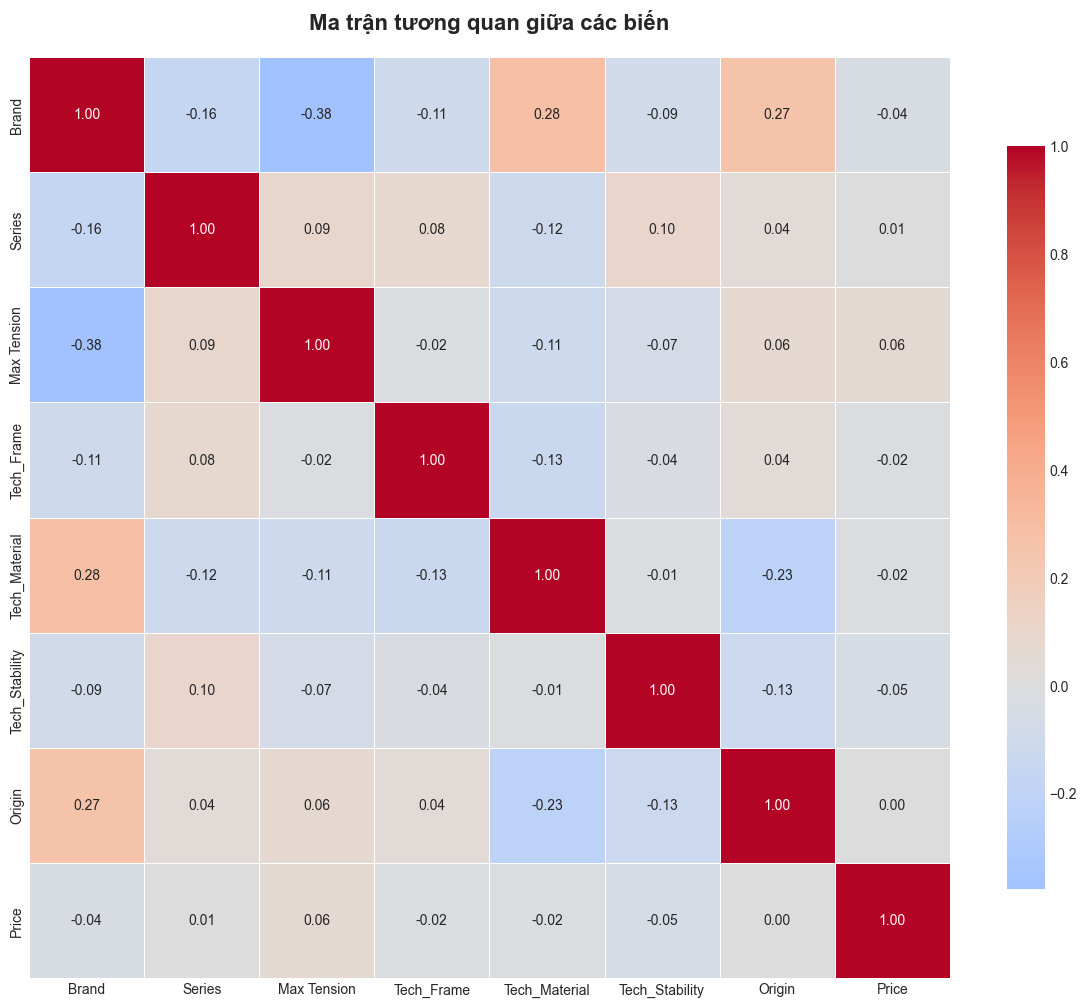


Correlation với Price:
Max Tension         :  0.0633
Series              :  0.0091
Origin              :  0.0049
Tech_Material       : -0.0190
Tech_Frame          : -0.0198
Brand               : -0.0436
Tech_Stability      : -0.0463


In [23]:
# Tạo ma trận tương quan cho các biến số
# Label encode các biến để tính correlation
df_corr = df.copy()
le = LabelEncoder()

for col in ['Brand', 'Series', 'Version', 'Origin', 'Tech_Frame', 'Tech_Material', 'Tech_Stability']:
    if col in df_corr.columns:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Tính correlation matrix
correlation_matrix = df_corr.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Hiển thị correlation với Price
print("\nCorrelation với Price:")
price_corr = correlation_matrix['Price'].sort_values(ascending=False)
for feature, corr_value in price_corr.items():
    if feature != 'Price':
        print(f"{feature:20s}: {corr_value:7.4f}")

## 3. Data Preprocessing

In [24]:
# Xử lý missing values - fill with 'Unknown'
df_processed = df.copy()
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        df_processed[col] = df_processed[col].fillna('Unknown')
    else:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print("Missing values after preprocessing:")
print(df_processed.isnull().sum())
print("\n✓ Preprocessing completed!")

Missing values after preprocessing:
Brand             0
Series            0
Max Tension       0
Tech_Frame        0
Tech_Material     0
Tech_Stability    0
Origin            0
Price             0
dtype: int64

✓ Preprocessing completed!


## 4. Feature Engineering - One-Hot Encoding

Áp dụng One-Hot Encoding cho các cột: Brand, Origin, Tech_Frame, Tech_Material, Tech_Stability

In [25]:
# Định nghĩa các cột cần One-Hot Encoding
onehot_columns = ['Brand', 'Origin', 'Tech_Frame', 'Tech_Material', 'Tech_Stability']

print("Applying One-Hot Encoding to columns:")
for col in onehot_columns:
    print(f"  - {col}: {df_processed[col].nunique()} unique values")

# Áp dụng One-Hot Encoding
df_encoded = pd.get_dummies(df_processed, columns=onehot_columns, prefix=onehot_columns, drop_first=True)

print(f"\n✓ One-Hot Encoding completed!")
print(f"Shape before encoding: {df_processed.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"Number of new features created: {df_encoded.shape[1] - df_processed.shape[1]}")

Applying One-Hot Encoding to columns:
  - Brand: 8 unique values
  - Origin: 4 unique values
  - Tech_Frame: 163 unique values
  - Tech_Material: 162 unique values
  - Tech_Stability: 207 unique values

✓ One-Hot Encoding completed!
Shape before encoding: (6260, 8)
Shape after encoding: (6260, 542)
Number of new features created: 534


## 5. Feature Engineering - Target Encoding

Áp dụng Target Encoding cho cột Series (sử dụng mean của Price)

In [26]:
# Target Encoding cho Series
print("Target Encoding for 'Series' column:")
print(f"Unique values in Series: {df_encoded['Series'].nunique()}")

# Tính mean của Price cho mỗi Series
series_price_mean = df_encoded.groupby('Series')['Price'].mean()
print(f"\nTop 10 Series by average price:")
print(series_price_mean.sort_values(ascending=False).head(10))

# Áp dụng Target Encoding
df_encoded['Series_Encoded'] = df_encoded['Series'].map(series_price_mean)

# Xóa cột Series gốc
df_encoded = df_encoded.drop('Series', axis=1)

print(f"\n✓ Target Encoding completed!")
print(f"Series_Encoded statistics:")
print(df_encoded['Series_Encoded'].describe())

Target Encoding for 'Series' column:
Unique values in Series: 347

Top 10 Series by average price:
Series
Slayer       9.610075e+08
WOOD-N80     7.140002e+06
M78          6.440018e+06
Iron         5.490006e+06
Woods        5.143799e+06
SPIDER       5.099968e+06
Spider       4.989960e+06
N7           4.988985e+06
N90          4.940036e+06
Abs-Power    4.900032e+06
Name: Price, dtype: float64

✓ Target Encoding completed!
Series_Encoded statistics:
count    6.260000e+03
mean     2.645930e+06
std      2.425176e+07
min      3.599988e+05
25%      1.399660e+06
50%      1.920004e+06
75%      2.580644e+06
max      9.610075e+08
Name: Series_Encoded, dtype: float64


## 6. Train-Test Split

In [27]:
# Tách features và target
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✓ Data split completed!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Train-Test ratio: {X_train.shape[0]/X_test.shape[0]:.2f}:1")

Features shape: (6260, 541)
Target shape: (6260,)
Number of features: 541

✓ Data split completed!
Training set: 5008 samples
Testing set: 1252 samples
Train-Test ratio: 4.00:1


## 7. XGBoost Model Training

Huấn luyện mô hình XGBoost và đo thời gian training

In [31]:
# Khởi tạo XGBoost model với siêu tham số được tối ưu để giảm overfitting
model = xgb.XGBRegressor(
    n_estimators=500,              # Giảm từ 500 để tránh overfit
    max_depth=10,                   # Giảm từ 10 xuống 5 (cây nông hơn)
    learning_rate=0.1,             # Tăng từ 0.08 (học chậm hơn)  
    subsample=0.8,                 # Random sampling 80% data mỗi iteration
    colsample_bytree=0.8,          # Random sampling 80% features mỗi tree
    reg_alpha=1,                   # L1 regularization
    reg_lambda=1,                  # L2 regularization
    min_child_weight=3,            # Tăng để tránh overfit
    random_state=42,
    n_jobs=-1,
)

print("XGBoost Model Parameters:")
print(model.get_params())

# Training và đo thời gian với early stopping
print("\n" + "="*60)
print("TRAINING MODEL...")
print("="*60)

start_time = time.time()
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
training_time = time.time() - start_time

print(f"\n✓ Training completed!")
print(f"Training time: {training_time:.4f} seconds ({training_time/60:.2f} minutes)")
print(f"Best iteration: {model.best_iteration if hasattr(model, 'best_iteration') else 'N/A'}")

XGBoost Model Parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 10, 'max_leaves': None, 'min_child_weight': 3, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

TRAINING MODEL...

✓ Training completed!
Training time: 2.4721 sec

## 8. Model Evaluation

Đánh giá độ chính xác của mô hình với nhiều metrics

In [32]:
# Dự đoán và đo thời gian
start_time = time.time()
y_train_pred = model.predict(X_train)
train_pred_time = time.time() - start_time

start_time = time.time()
y_test_pred = model.predict(X_test)
test_pred_time = time.time() - start_time

# Tính toán metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Hiển thị kết quả
print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print("\n📊 TRAINING SET:")
print(f"  MAE:  {train_mae:,.0f} VND")
print(f"  MSE:  {train_mse:,.0f}")
print(f"  RMSE: {train_rmse:,.0f} VND")
print(f"  R² Score: {train_r2:.4f}")
print(f"  Prediction time: {train_pred_time:.4f} seconds")

print("\n📊 TESTING SET:")
print(f"  MAE:  {test_mae:,.0f} VND")
print(f"  MSE:  {test_mse:,.0f}")
print(f"  RMSE: {test_rmse:,.0f} VND")
print(f"  R² Score: {test_r2:.4f}")
print(f"  Prediction time: {test_pred_time:.4f} seconds")

print("\n📈 OVERALL PERFORMANCE:")
print(f"  Accuracy (R²): {test_r2*100:.2f}%")
print(f"  Average error: ±{test_mae:,.0f} VND")
print(f"  Total time: Training={training_time:.2f}s + Prediction={test_pred_time:.4f}s")

MODEL EVALUATION RESULTS

📊 TRAINING SET:
  MAE:  146,465 VND
  MSE:  89,916,698,180
  RMSE: 299,861 VND
  R² Score: 0.9999
  Prediction time: 0.0467 seconds

📊 TESTING SET:
  MAE:  195,964 VND
  MSE:  138,554,143,803
  RMSE: 372,229 VND
  R² Score: 0.9296
  Prediction time: 0.0341 seconds

📈 OVERALL PERFORMANCE:
  Accuracy (R²): 92.96%
  Average error: ±195,964 VND
  Total time: Training=2.47s + Prediction=0.0341s


## 9. Performance Visualization

Trực quan hóa kết quả dự đoán

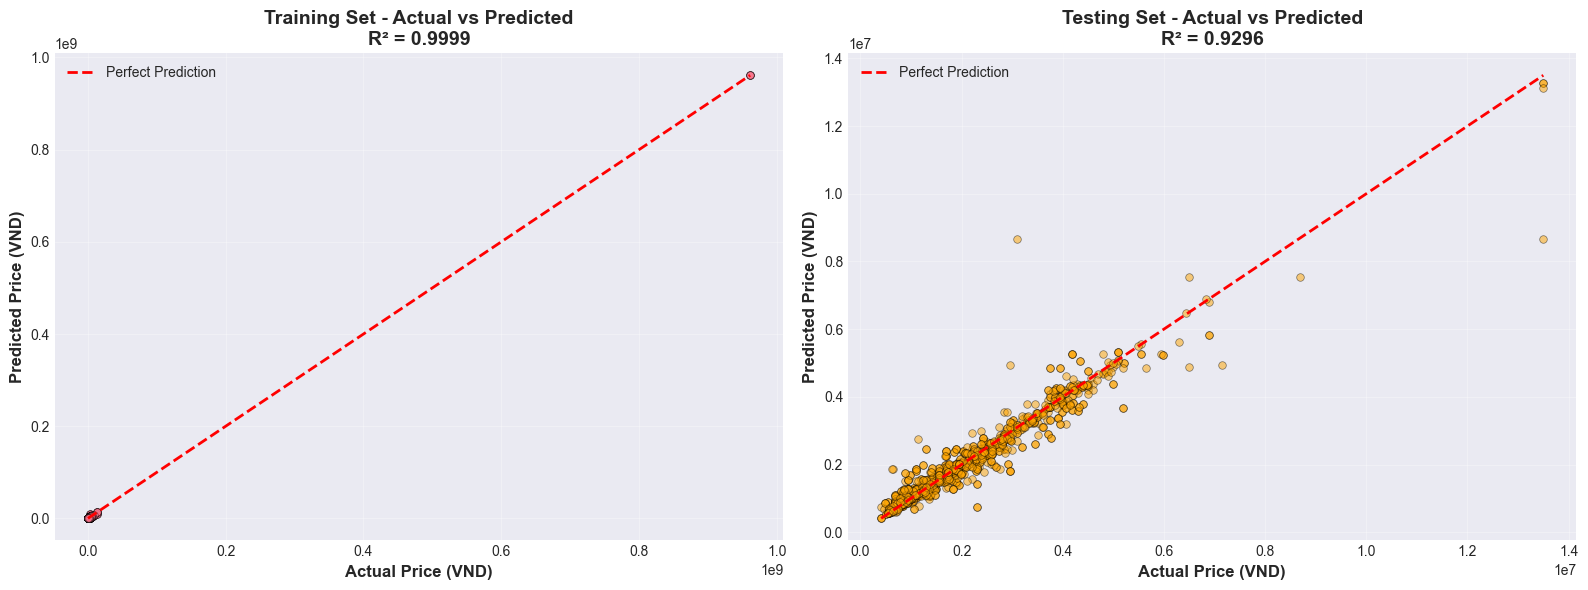

In [33]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (VND)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Price (VND)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Training Set - Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (VND)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Price (VND)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Testing Set - Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
features = X_train.columns
importances = model.feature_importances_

# Sắp xếp theo độ quan trọng
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.tail(10).plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 Feature Importance - XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu ảnh để chèn vào LaTeX
plt.savefig('feature_importance.png', dpi=300)
plt.show()

NameError: name 'X_train' is not defined